# The Price is Right

Today we build a more complex solution for estimating prices of goods.

1. Day 2.0 notebook: create a RAG database with our 400,000 training data
2. Day 2.1 notebook: visualize in 2D
3. Day 2.2 notebook: visualize in 3D
4. Day 2.3 notebook: build and test a RAG pipeline with GPT-4o-mini
5. Day 2.4 notebook: (a) bring back our Random Forest pricer (b) Create a Ensemble pricer that allows contributions from all the pricers

Phew! That's a lot to get through in one day!

## PLEASE NOTE:

We already have a very powerful product estimator with our proprietary, fine-tuned LLM. Most people would be very satisfied with that! The main reason we're adding these extra steps is to deepen your expertise with RAG and with Agentic workflows.

## We will go fast today! Hold on to your hat..

In [1]:
# imports

import os
import re
from dotenv import load_dotenv
import pickle
from openai import OpenAI
from sentence_transformers import SentenceTransformer
import chromadb

import sys
sys.path.append('../week6') 
from testing import Tester

In [2]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [3]:
openai = OpenAI()

In [4]:
# Load in the test pickle file
# See the section "Back to the PKL files" in the day2.0 notebook
# for instructions on obtaining this test.pkl file

with open('../week6/test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

In [5]:
print(f"Test length: {len(test)}")

Test length: 3000


In [6]:
def make_context(similars, prices):
    message = "To provide some context, here are some other items that might be similar to the item you need to estimate.\n\n"
    for similar, price in zip(similars, prices):
        message += f"Potentially related product:\n{similar}\nPrice is ${price:.2f}\n\n"
    return message

In [7]:
def messages_for(item, similars, prices):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = make_context(similars, prices)
    user_prompt += "And now the question for you:\n\n"
    user_prompt += item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [8]:
DB = "products_vectorstore"

In [9]:
client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection('products')

In [10]:
print(f"📊 向量庫中紀錄數量：{collection.count()} 筆")

📊 向量庫中紀錄數量：100000 筆


In [11]:
def description(item):
    text = item.prompt.replace("How much does this cost to the nearest dollar?\n\n", "")
    return text.split("\n\nPrice is $")[0]

In [12]:
description(test[0])

'Outlaw Racing OR3785 Complete Full Engine Gasket Set Compatible with Yamaha YZ250 Dirt Kit\nOutlaw Racing Complete Gasket Kits are exactly what you need to get your bike rebuilt and running right! Using materials such as Stainless Steel, Fluoroviton and Teflon, our gaskets are made to exact OEM specs but with better materials to last longer and keep your bike running stronger. Each kit will contain the exact gaskets, seals and o-rings you need to re-assemble your top and bottom engine components after a standard rebuild (no overbore sizes are available), and require no trimming or modification. ✅ Exactly what you need to get your bike rebuilt and running right! ✅ Each kit will contain the exact gaskets, seals, and o-rings you'

In [13]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

In [14]:
def vector(item):
    return model.encode([description(item)])

## Find 5 similar results by using collection.query
- n_results=5

In [15]:
def find_similars(item):
    results = collection.query(query_embeddings=vector(item).astype(float).tolist(), n_results=5) # Return 5 similars 
    documents = results['documents'][0][:]
    prices = [m['price'] for m in results['metadatas'][0][:]]
    return documents, prices

In [16]:
print(test[1].prompt)

How much does this cost to the nearest dollar?

LEMAXELERS Compatible with Galaxy S22 Plus Case Slim Mirror Design Clear View Flip Bookstyle Ultra Slim Protecter Shell with Kickstand Protective Cover for Samsung Galaxy S22 Plus Mirror PU Black
LEMAXELERS is committed to give customer an excellent shopping experience, if you have any questions, please do not hesitate to contact us. We will reply you in 24 hours. Compatible Model Compatible with Samsung Galaxy S22 Plus only 1.Made of high quality hard plastic and PU leather, the front and back cover is PC, the connecting portion is premium PU leather,the whole case looks slim without adding a lot of weight. 2. High quality synthetic PU leather + inner soft slim TPU silicone bumper. Mirror Function The front Mirror cover consists of a high quality PC. Please note that he

Price is $12.00


In [17]:
documents, prices = find_similars(test[1])

In [18]:
# Due to n_results=5
print(f"Documents length: {len(documents)}")
print(f"Prices length: {len(prices)}")

Documents length: 5
Prices length: 5


In [19]:
print(make_context(documents, prices))

To provide some context, here are some other items that might be similar to the item you need to estimate.

Potentially related product:
MEMAXELUS Compatible with Samsung Galaxy S22 Ultra 5G Phone Case Wallet Case with Kickstand Card Holder Slot Cute Cover Premium PU Leather Protective Phone Case for Samsung S22 Ultra 5G White Tiger BX
★Compatible Model Only for Samsung Galaxy S22 Ultra 5G, Please confirm your phone model. ★Kickstand Support This feature for comfortable Video Viewing, Reading, & Face Time.the strong magnet stay closed to keep your belongings security. ★Full Body Protection Our cell phone case has Four corner protection by high quality soft TPU inner skin shell. Shock absorbent material. Smooth and sturdy leather which prevents damage from Dust, Dirt and Scratches, Keep your phone bright and beautiful all the time. ★Convenient The flip case Allows Charging without removing the case, card slots and a
Price is $10.99

Potentially related product:
MATEPROX Compatible with 

In [20]:
print(messages_for(test[1], documents, prices))

[{'role': 'system', 'content': 'You estimate prices of items. Reply only with the price, no explanation'}, {'role': 'user', 'content': 'To provide some context, here are some other items that might be similar to the item you need to estimate.\n\nPotentially related product:\nMEMAXELUS Compatible with Samsung Galaxy S22 Ultra 5G Phone Case Wallet Case with Kickstand Card Holder Slot Cute Cover Premium PU Leather Protective Phone Case for Samsung S22 Ultra 5G White Tiger BX\n★Compatible Model Only for Samsung Galaxy S22 Ultra 5G, Please confirm your phone model. ★Kickstand Support This feature for comfortable Video Viewing, Reading, & Face Time.the strong magnet stay closed to keep your belongings security. ★Full Body Protection Our cell phone case has Four corner protection by high quality soft TPU inner skin shell. Shock absorbent material. Smooth and sturdy leather which prevents damage from Dust, Dirt and Scratches, Keep your phone bright and beautiful all the time. ★Convenient The f

In [21]:
def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [22]:
get_price("The price for this is $99.99")

99.99

In [23]:
# The function for gpt-4o-mini

def gpt_4o_mini_rag(item):
    documents, prices = find_similars(item)
    response = openai.chat.completions.create(
        model="gpt-4o-mini", 
        messages=messages_for(item, documents, prices),
        seed=42,
        max_tokens=5
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [24]:
gpt_4o_mini_rag(test[1])

12.99

In [25]:
test[1].price

11.98

Process status: 10% | Hits Rate so far: 88.0%
Process status: 20% | Hits Rate so far: 84.0%
Process status: 30% | Hits Rate so far: 82.7%
Process status: 40% | Hits Rate so far: 82.0%
Process status: 50% | Hits Rate so far: 84.0%
Process status: 60% | Hits Rate so far: 86.7%
Process status: 70% | Hits Rate so far: 88.0%
Process status: 80% | Hits Rate so far: 88.0%
Process status: 90% | Hits Rate so far: 88.9%
Process status: 100% | Hits Rate so far: 88.4%


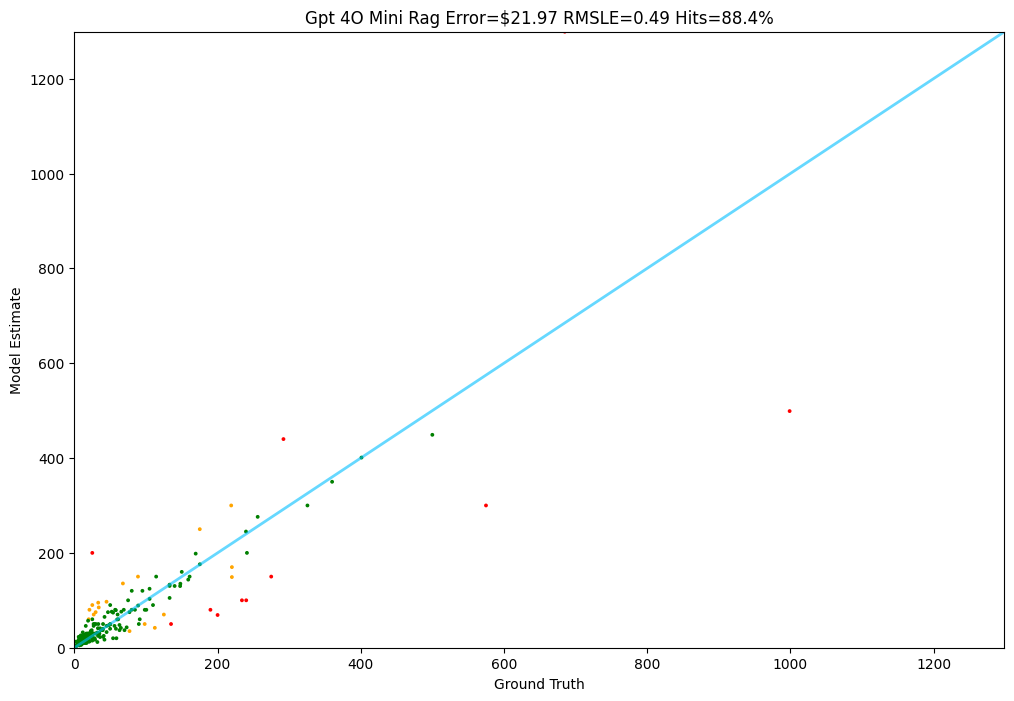

In [26]:
Tester.test(gpt_4o_mini_rag, test)

## Optional Extra: Trying a DeepSeek API call instead of OpenAI

If you have a DeepSeek API key, we will use it here as an alternative implementation; otherwise skip to the next section..

In [27]:
# Connect to DeepSeek using the OpenAI client python library

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")
deepseek_via_openai_client = OpenAI(api_key=deepseek_api_key,base_url="https://api.deepseek.com")

In [28]:
# Added some retry logic here because DeepSeek is very oversubscribed and sometimes fails..

def deepseek_api_rag(item):
    documents, prices = find_similars(item)
    retries = 8
    done = False
    while not done and retries > 0:
        try:
            response = deepseek_via_openai_client.chat.completions.create(
                model="deepseek-chat", 
                messages=messages_for(item, documents, prices),
                seed=42,
                max_tokens=8
            )
            reply = response.choices[0].message.content
            done = True
        except Exception as e:
            print(f"Error: {e}")
            retries -= 1
    return get_price(reply)

In [29]:
deepseek_api_rag(test[1])

12.99

Process status: 10% | Hits Rate so far: 92.0%
Process status: 20% | Hits Rate so far: 88.0%
Process status: 30% | Hits Rate so far: 85.3%
Process status: 40% | Hits Rate so far: 84.0%
Process status: 50% | Hits Rate so far: 84.0%
Process status: 60% | Hits Rate so far: 86.0%
Process status: 70% | Hits Rate so far: 86.3%
Process status: 80% | Hits Rate so far: 87.0%
Process status: 90% | Hits Rate so far: 87.1%
Process status: 100% | Hits Rate so far: 85.2%


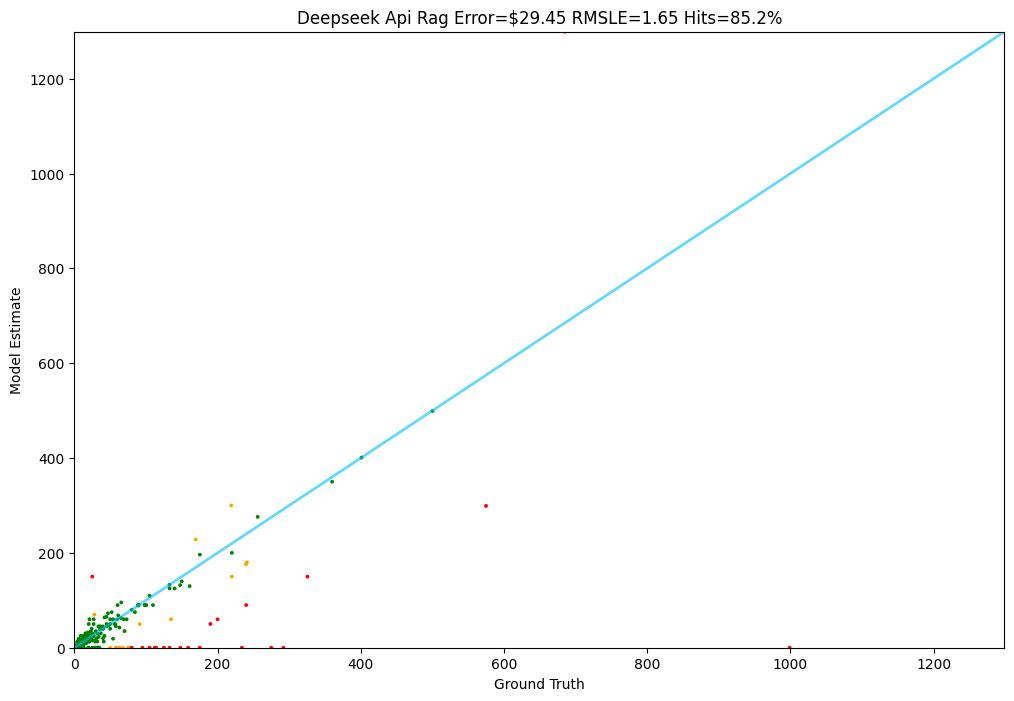

In [30]:
Tester.test(deepseek_api_rag, test)

## And now to wrap this in an "Agent" class

In [31]:
from agents.frontier_agent import FrontierAgent

In [32]:
# Let's print the logs so we can see what's going on

import logging
root = logging.getLogger()
root.setLevel(logging.INFO)

In [33]:
agent = FrontierAgent(collection)

INFO:root:[Frontier Agent] Initializing Frontier Agent
INFO:root:[Frontier Agent] Frontier Agent is set up with DeepSeek
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:root:[Frontier Agent] Frontier Agent is ready


In [34]:
agent.price("Quadcast HyperX condenser mic for high quality podcasting")

INFO:root:[Frontier Agent] Frontier Agent is performing a RAG search of the Chroma datastore to find 5 similar products


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:[Frontier Agent] Frontier Agent has found similar products
INFO:root:[Frontier Agent] Frontier Agent is about to call deepseek-chat with context including 5 similar products
INFO:httpx:HTTP Request: POST https://api.deepseek.com/chat/completions "HTTP/1.1 200 OK"
INFO:root:[Frontier Agent] Frontier Agent completed - predicting $149.99


149.99

In [35]:
from agents.specialist_agent import SpecialistAgent

In [36]:
agent2 = SpecialistAgent()

INFO:root:[Specialist Agent] Specialist Agent is initializing - connecting to modal
INFO:root:[Specialist Agent] Specialist Agent is ready


In [37]:
agent2.price("Quadcast HyperX condenser mic for high quality podcasting")

INFO:root:[Specialist Agent] Specialist Agent is calling remote fine-tuned model
INFO:root:[Specialist Agent] Specialist Agent completed - predicting $60.00


60.0